In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt


from argparse import Namespace

from training import ModelTrainer, TrajectoryGenerator

from models import SingleTimeStep

from experiments import entropy_loss_TUR, entropy_infer_TUR, force_loss, force_infer, od_force_loss, od_dtlogf_loss
from experiments import entropy_loss_ML, entropy_infer_ML, od_entropy_loss_ML, od_entropy_infer_ML


import fivebeads

from fivebeads import params, simulate_five_spring_overdamped, five_beads
#from free_diffusion import params, simulate_free_diffusion_underdamped, realepr, traj_dEnt




## OD EXAMPLE TRAIN/INFERENCE IF LOSS IS FOR FORCE

In [4]:
training_options = Namespace()
model_options = Namespace()

training_options.n_epoch = 1_500
training_options.epoch_s = 800_000

training_options.n_iter = 200
training_options.iter_s = 4_096

training_options.n_infer = 1
training_options.infer_s = 10_000

training_options.lr = 1E-4
training_options.wd = 5E-5

training_options.patience = 5
training_options.min_delta = 0

###Earlystop
training_options.patience = 5
training_options.min_delta = 0

model_options.n_input = 5
model_options.n_hidden = 32
model_options.n_output = 5
# this is how many hidden layers to use
model_options.num_inner = 2

In [8]:
#params stores information for the sim
print(params)
#create the theo model to test the accuracy of nns
theo_model = fivebeads.five_beads(params['init'], 2 * np.linspace(params['kBT'][0], params['kBT'][1], 5))

{'dt': 0.01, 'num_steps': 5, 'init': array([ 0.56, -0.23,  0.14, -0.12,  0.09,  0.87, -0.15,  0.08, -0.19,
        0.92, -0.21,  0.11,  0.68, -0.17,  0.79]), 'kBT': [1, 2], 'mob': 1, 'k': 1, 'coarse': 1, 'Dt': 0.01}


In [6]:
#gamma is the force since we are in free diffusion
#params['gamma'] = 1

#this is the initial distribution params for the free diffusion
#params['init'] = [1,1,1]

# we want to test coarse data, lets say we only see every 10 steps
#params['coarse'] = 1
#params['dt'] = .01

#how long of a trajectory to simulate 
# we'll get the force for 1 step only, obviously
# it is set to 20 because we need to simulater 20 steps to get one step at coarse = 10 with inferring velocity
params['num_steps'] = 2
#print(params)
model_options

Namespace(n_input=5, n_hidden=32, n_output=5, num_inner=2)

In [7]:
WeightFunction = SingleTimeStep(model_options)
Fivebeads = TrajectoryGenerator(simulate_five_spring_overdamped, params)
Fivebeads.infinite_data = False

#need to set this, so that the simulator knows to return estimated velocity insead of the real one
#FreeDiffusion.infer_velocity = True

optimizer = torch.optim.Adam
#optimizer = torch.optim.SGD

Force = ModelTrainer(WeightFunction, Fivebeads, optimizer, od_force_loss, force_infer, training_options)

Force.validation_data = Fivebeads.generate_batch(200_000)

In [8]:
untrained_output, untrained_test_trajectories = Force.infer(return_trajectories=True)

In [9]:
# can edit training options here if you want
#training_options.n_epoch = 150
#training_options.epoch_s = 10_000
#training_options.n_iter = 1
#training_options.iter_s = 10_000

Force.train()

  0%|          | 0/1500 [00:00<?, ?it/s]

  5%|▌         | 76/1500 [01:16<23:57,  1.01s/it]


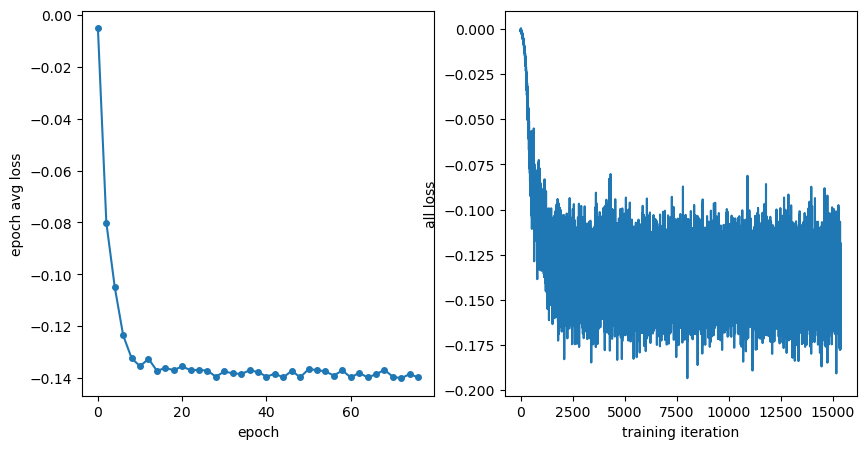

In [10]:
fig, ax = plt.subplots(1,2)
plt.close()
Force.plot_training_loss(ax=ax)

In [160]:
output, test_trajectories = Force.infer(return_trajectories = True)

In [11]:
A = torch.tensor([
        [-2.0, 1, 0, 0, 0],
        [1, -2, 1, 0, 0],
        [0, 1, -2, 1, 0],
        [0, 0, 1, -2, 1],
        [0, 0, 0, 1, -2]
    ])
phasedata = TrajectoryGenerator(simulate_five_spring_overdamped, params).batch(1000)
theo_force = torch.einsum('ij,kj->ik',phasedata[:,0,:],A) 
nn_force= WeightFunction(phasedata[:,0,:])

def r2_score(y_true, y_pred):
    """
    Compute the R^2 (coefficient of determination) score.

    Parameters:
    y_true (torch.Tensor): Ground truth values.
    y_pred (torch.Tensor): Predicted values.

    Returns:
    float: R^2 score.
    """
    ssr = torch.sum((y_true - y_pred) ** 2)
    tss = torch.sum((y_true - torch.mean(y_true)) ** 2)
    r2 = 1 - (ssr / tss)
    return r2.item()
r2_score(theo_force,nn_force)

0.9949023723602295

## EXAMPLE TRAIN/INFERENCE IF LOSS IS FOR EP
### also, creating 2 models for different loss/inference functions
### here we use both our original TUR based functions, and the new "ML" ones that come from the L2 norm

In [12]:
# how long of a trajectory to get the EP for, here we can accomodate more than one step
# but it is still rate based ultimately
params['num_steps'] = 2

#this is the initial distribution params for the free diffusion
#params['init'] = [.6,.8,.5]


#for non coarse data
#params['coarse'] = 1
#params['dt'] = .001

print(params)
#Theo part
theo_model = fivebeads.five_beads(params['init'], 2 * np.linspace(params['kBT'][0], params['kBT'][1], 5))


{'dt': 0.01, 'num_steps': 2, 'init': array([ 0.56, -0.23,  0.14, -0.12,  0.09,  0.87, -0.15,  0.08, -0.19,
        0.92, -0.21,  0.11,  0.68, -0.17,  0.79]), 'kBT': [1, 2], 'mob': 1, 'k': 1, 'coarse': 1, 'Dt': 0.01}


In [13]:
WeightFunction = SingleTimeStep(model_options)
WeightFunction_ML_u = SingleTimeStep(model_options)

Fivebeads = TrajectoryGenerator(simulate_five_spring_overdamped, params)

#by default, velocity is not inferred so no need to change
#print('inferring velocity:',FreeDiffusion.infer_velocity)

optimizer = torch.optim.Adam

#instead of testing corase grained data, let's see the difference between the TUR based and ML based methods:

# old loss/inference based on TUR
#EntProd = ModelTrainer(WeightFunction, Fivebeads, optimizer, entropy_loss_TUR, entropy_infer_TUR, training_options)
# new loss/inference based on ML
EntProd_ML = ModelTrainer(WeightFunction_ML_u, Fivebeads, optimizer, od_entropy_loss_ML, od_entropy_infer_ML, training_options)
EntProd_ML.validation_data = Fivebeads.generate_batch(200_000)

In [14]:
EntProd_ML.train()

  3%|▎         | 46/1500 [01:08<36:00,  1.49s/it]


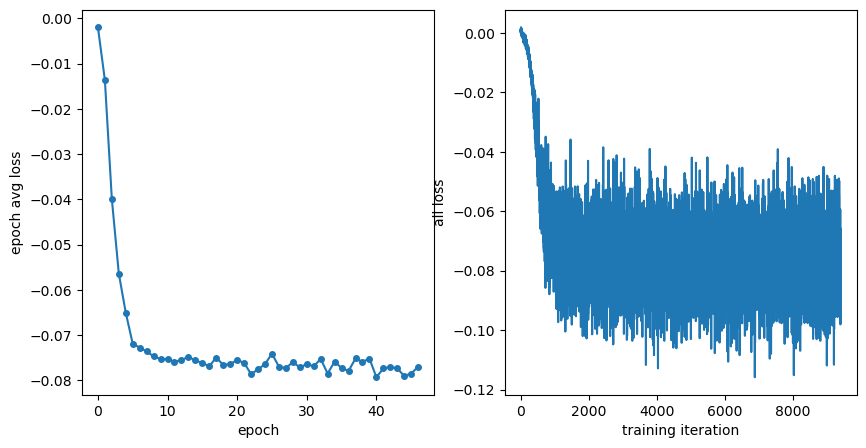

In [15]:
fig, ax = plt.subplots(1,2)
plt.close()
EntProd_ML.plot_training_loss(ax=ax)

In [16]:
phasedata_test = TrajectoryGenerator(simulate_five_spring_overdamped, params).batch(1000)
theo_u = theo_model.u(phasedata_test[:,0,:],0)
nn_u= WeightFunction_ML_u(phasedata_test[:,0,:])

def r2_score(y_true, y_pred):
    """
    Compute the R^2 (coefficient of determination) score.

    Parameters:
    y_true (torch.Tensor): Ground truth values.
    y_pred (torch.Tensor): Predicted values.

    Returns:
    float: R^2 score.
    """
    ssr = torch.sum((y_true - y_pred) ** 2)
    tss = torch.sum((y_true - torch.mean(y_true)) ** 2)
    r2 = 1 - (ssr / tss)
    return r2.item()
r2_score(theo_u,nn_u)

0.9920904030908362

## To estimate the stochastic entropy production, $\partial_{t} \log f$ is needed

In [169]:
'''
training_options = Namespace()
model_options = Namespace()

training_options.n_epoch = 1
training_options.epoch_s = 800_000

training_options.n_iter = 55_000
training_options.iter_s = 4_096

training_options.n_infer = 20
training_options.infer_s = 50_000

training_options.lr = 1E-4
training_options.wd = 5E-5
'''
model_options.n_input = 5
model_options.n_hidden = 32
model_options.n_output = 1
model_options.num_inner = 2

In [170]:
# how long of a trajectory to get the EP for, here we can accomodate more than one step
# but it is still rate based ultimately
params['num_steps'] = 2

#this is the initial distribution params for the free diffusion
#params['init'] = [.6,.8,.5]


#for non coarse data
#params['coarse'] = 1
#params['dt'] = .001

print(params)
#Theo part


{'dt': 0.01, 'num_steps': 2, 'init': array([ 0.56, -0.23,  0.14, -0.12,  0.09,  0.87, -0.15,  0.08, -0.19,
        0.92, -0.21,  0.11,  0.68, -0.17,  0.79]), 'kBT': [1, 2], 'mob': 1, 'k': 1, 'coarse': 1, 'Dt': 0.01}


In [171]:
WeightFunction = SingleTimeStep(model_options)

Fivebeads = TrajectoryGenerator(simulate_five_spring_overdamped, params)

#by default, velocity is not inferred so no need to change
#print('inferring velocity:',FreeDiffusion.infer_velocity)

optimizer = torch.optim.Adam

#instead of testing corase grained data, let's see the difference between the TUR based and ML based methods:


#loss/inference based on ML
dtlogf = ModelTrainer(WeightFunction, Fivebeads, optimizer, od_dtlogf_loss, od_entropy_infer_ML, training_options)
dtlogf.validation_data = Fivebeads.generate_batch(200_000)

In [172]:
dtlogf.train()

  6%|▋         | 94/1500 [02:21<35:12,  1.50s/it]


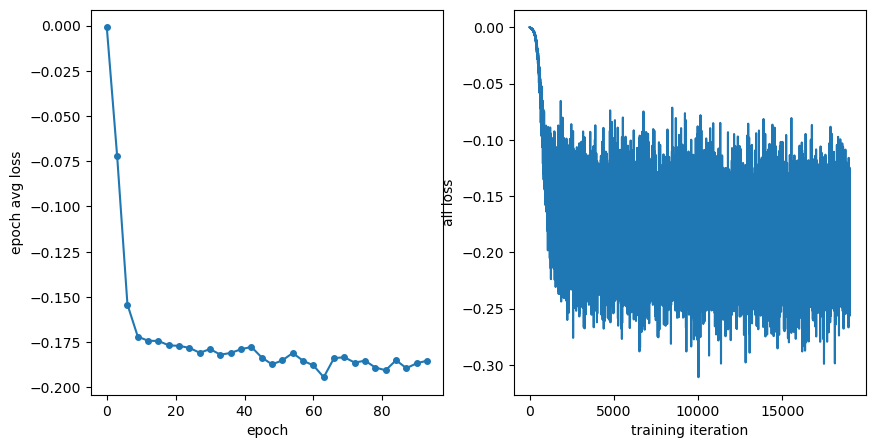

In [173]:
fig, ax = plt.subplots(1,2)
plt.close()
dtlogf.plot_training_loss(ax=ax)

In [175]:
phasedata_test = dtlogf.validation_data
theo_dtlogf = torch.from_numpy(theo_model.dtlogf((phasedata_test[:,0,:]).numpy(),0))
nn_dtlogf= WeightFunction(phasedata_test[:,0,:])

r2_score(theo_dtlogf,nn_dtlogf)

0.981012493047455

## An example try to estimate the EP for long trajs, we need to train $u$ and $d_{t}logf$

In [2]:
Fivebeads = TrajectoryGenerator(simulate_five_spring_overdamped, params)
Fivebeads.infinite_data = False
params['num_steps'] = 5
print(params)

{'dt': 0.01, 'num_steps': 5, 'init': array([ 0.56, -0.23,  0.14, -0.12,  0.09,  0.87, -0.15,  0.08, -0.19,
        0.92, -0.21,  0.11,  0.68, -0.17,  0.79]), 'kBT': [1, 2], 'mob': 1, 'k': 1, 'coarse': 1}


In [3]:
training_options = Namespace()
model_options = Namespace()

training_options.n_epoch = 1_500
training_options.epoch_s = 800_000

training_options.n_iter = 200
training_options.iter_s = 4_096

training_options.n_infer = 1
training_options.infer_s = 10_000

training_options.lr = 1E-4
training_options.wd = 5E-5

training_options.patience = 10
training_options.min_delta = 0

model_options.n_input = 5
model_options.n_hidden = 32
model_options.n_output = 5
# this is how many hidden layers to use
model_options.num_inner = 2

# Generate long data
total_data_train= TrajectoryGenerator(simulate_five_spring_overdamped, params).batch(training_options.epoch_s)
total_data_validate= TrajectoryGenerator(simulate_five_spring_overdamped, params).batch(200_000)
# Weight function
WeightFunction_u_multisteps = [SingleTimeStep(model_options) for _ in range(params['num_steps'])]


In [5]:
# Used to save training data
optimizer = torch.optim.Adam
Fivebeads_multisteps = [TrajectoryGenerator(simulate_five_spring_overdamped, params) for _ in range(params['num_steps'])]
EntProd_ML_multisteps  = [ModelTrainer(WeightFunction_u_multisteps[0], Fivebeads_multisteps[0], optimizer, od_entropy_loss_ML, od_entropy_infer_ML, training_options) for _ in range(params['num_steps'])]

In [6]:
# Training step by step
for step in range(params['num_steps']-1):
    EntProd_ML_multisteps[step] = ModelTrainer(WeightFunction_u_multisteps[step], Fivebeads_multisteps[step], optimizer, od_entropy_loss_ML, od_entropy_infer_ML, training_options)
    # Setting up training data and validation data
    Fivebeads_multisteps[step].infinite_data = False
    if step!=params['num_steps']-2:
        Fivebeads_multisteps[step].data = total_data_train[:,step:step+2,:]
        EntProd_ML_multisteps[step].validation_data = total_data_validate[:,step:step+2,:] 
    if step==params['num_steps']-2:
        Fivebeads_multisteps[step].data = total_data_train[:,-2:,:]
        EntProd_ML_multisteps[step].validation_data = total_data_validate[:,-2:,:] 

    #print(hasattr(EntProd_ML_multisteps[step], 'validation_data'))  # Check if 'data' exists
    print(f'Training step {step}')
    EntProd_ML_multisteps[step].train()
    ##Reset parameter every 10 steps
    #if (step+1)%10 !=0:
    WeightFunction_u_multisteps[step+1].load_state_dict(WeightFunction_u_multisteps[step].state_dict())

    


Training step 0


  0%|          | 0/1500 [00:00<?, ?it/s]

  6%|▌         | 89/1500 [01:35<25:07,  1.07s/it]


Training step 1


  2%|▏         | 31/1500 [00:36<28:29,  1.16s/it]


Training step 2


  1%|▏         | 21/1500 [00:24<28:49,  1.17s/it]


Training step 3


  1%|          | 11/1500 [00:14<31:41,  1.28s/it]


Text(0.5, 0, 'Step')

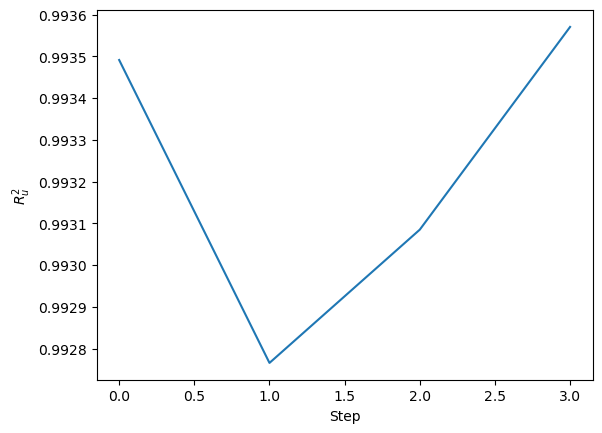

In [ ]:
##Show R^2 for function u

def r2_score(y_true, y_pred):
    """
    Compute the R^2 (coefficient of determination) score.

    Parameters:
    y_true (torch.Tensor): Ground truth values.
    y_pred (torch.Tensor): Predicted values.

    Returns:
    float: R^2 score.
    """
    ssr = torch.sum((y_true - y_pred) ** 2)
    tss = torch.sum((y_true - torch.mean(y_true)) ** 2)
    r2 = 1 - (ssr / tss)
    return r2.item()
r2_u=[]
for step in range(params['num_steps']-1):
    theo_u = theo_model.u(total_data_validate[:,step,:],0.01*step)
    nn_u= WeightFunction_u_multisteps[step](total_data_validate[:,step,:])
    r2_u.append(r2_score(theo_u,nn_u))

plt.plot(range(len(r2_u)),r2_u)
plt.ylabel('$R^2_u$')
plt.xlabel('Step')



In [10]:


model_options.n_input = 5
model_options.n_hidden = 32
model_options.n_output = 1
# this is how many hidden layers to use
model_options.num_inner = 2


WeightFunction_dtlogf_multisteps = [SingleTimeStep(model_options) for _ in range(params['num_steps'])]
# Used to save training data
dtlogf_multisteps  = [ModelTrainer(WeightFunction_dtlogf_multisteps[0], Fivebeads_multisteps[0], optimizer, od_dtlogf_loss, od_entropy_infer_ML, training_options) for _ in range(params['num_steps'])]

In [11]:
optimizer = torch.optim.Adam
for step in range(params['num_steps']-1):
    # Setting up data
    dtlogf_multisteps[step] = ModelTrainer(WeightFunction_dtlogf_multisteps[step], Fivebeads_multisteps[step], optimizer, od_dtlogf_loss, od_entropy_infer_ML, training_options)
    # Setting up training data and validation data
    Fivebeads_multisteps[step].infinite_data = False
    if step!=params['num_steps']-2:
        Fivebeads_multisteps[step].data = total_data_train[:,step:step+2,:]
        dtlogf_multisteps[step].validation_data = total_data_validate[:,step:step+2,:] 
    if step==params['num_steps']-2:
        Fivebeads_multisteps[step].data = total_data_train[:,-2:,:]
        dtlogf_multisteps[step].validation_data = total_data_validate[:,-2:,:] 

    #print(hasattr(EntProd_ML_multisteps[step], 'validation_data'))  # Check if 'data' exists
    print(f'Training step {step}')
    dtlogf_multisteps[step].train()
    ##Reset parameter every 10 steps
    #if (step+1)%10 !=0:
    WeightFunction_dtlogf_multisteps[step+1].load_state_dict(WeightFunction_dtlogf_multisteps[step].state_dict())

    


Training step 0


  8%|▊         | 122/1500 [02:02<23:08,  1.01s/it]


Training step 1


  2%|▏         | 26/1500 [00:27<26:00,  1.06s/it]


Training step 2


  3%|▎         | 44/1500 [00:44<24:24,  1.01s/it]


Training step 3


  1%|          | 10/1500 [00:10<26:23,  1.06s/it]


Text(0.5, 0, 'Step')

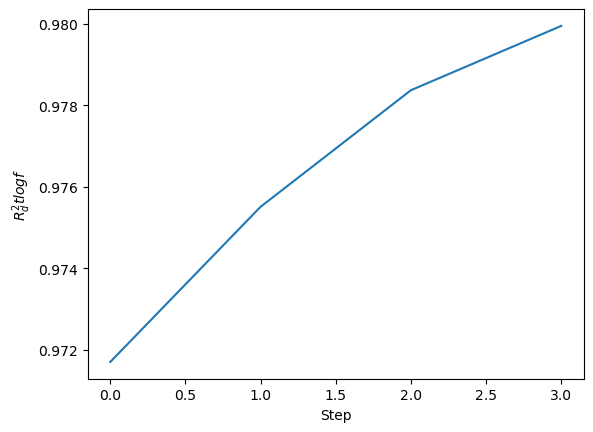

In [12]:
r2_dtlogf=[]
for step in range(params['num_steps']-1):
    theo_dtlogf = torch.from_numpy(theo_model.dtlogf(total_data_validate[:,step,:].numpy(),0.01*step))
    nn_dtlogf= WeightFunction_dtlogf_multisteps[step](total_data_validate[:,step,:])
    r2_dtlogf.append(r2_score(theo_dtlogf,nn_dtlogf))

plt.plot(range(len(r2_dtlogf)),r2_dtlogf)
plt.ylabel('$R^2_dtlogf$')
plt.xlabel('Step')

In [23]:
# Specify the start and the end
step_begin, step_end=0, params['num_steps']-1

In [31]:
diss_path = theo_model.path_diss_defi_theo(total_data_validate.numpy(), step_begin, step_end)
diss_path

array([0.58788887, 2.29775024, 1.91772208, ..., 0.37872858, 1.19167928,
       0.41323126])

In [32]:
diss_path_nn = theo_model.path_diss_nn( WeightFunction_u_multisteps, WeightFunction_dtlogf_multisteps, total_data_validate, step_begin, step_end)
diss_path_nn

tensor([[0.5163],
        [2.1209],
        [1.9662],
        ...,
        [0.3481],
        [1.2598],
        [0.4687]])

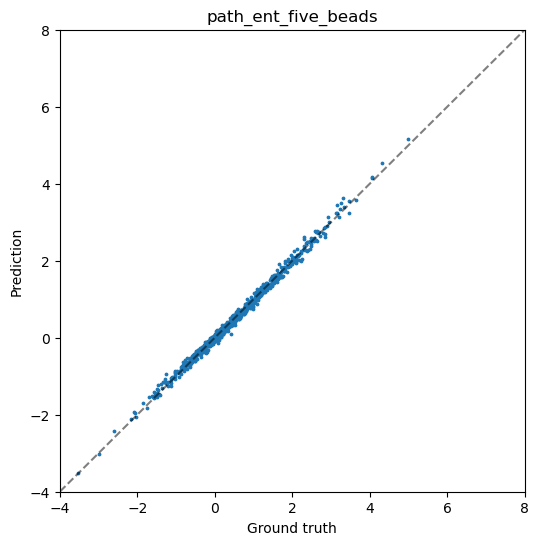

In [33]:
x1 = diss_path[:1000]
y1 = diss_path_nn[:1000]

x = np.linspace(-10, 10, 100)
y = x  # y = x

plt.figure(figsize=(6, 6))  # Width: 10 inches, Height: 6 inches

plt.plot(x, y, linestyle='--',alpha=0.5, color='black')  

plt.scatter(y1,x1, label='prediction',s=3)
plt.xlim(-4, 8)
plt.ylim(-4, 8)
# Add title and labels
plt.title('path_ent_five_beads')
plt.ylabel('Prediction')
plt.xlabel('Ground truth')
#plt.savefig("pre_gt_5beads.pdf",format="pdf")


# Show the plot
plt.show()
